<a href="https://colab.research.google.com/github/vgayathri13/VRSU/blob/main/VRSU_FrameSamplingProgram13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generating synthetic video...
  Video shape : (120, 64, 64)  (frames x height x width)
  Original FPS: 30
  Duration    : 4.0 seconds

=== Sampling Results ===
Original  : 120 frames  @ 30 FPS
Uniform   : 30 frames  (every 4 frames)   @ 7 FPS equivalent
Random    : 30 frames  (random subset)
Keyframe  : 1 frames  (scene-change based)
Averaged  : 30 frames  (avg pool, window=4)


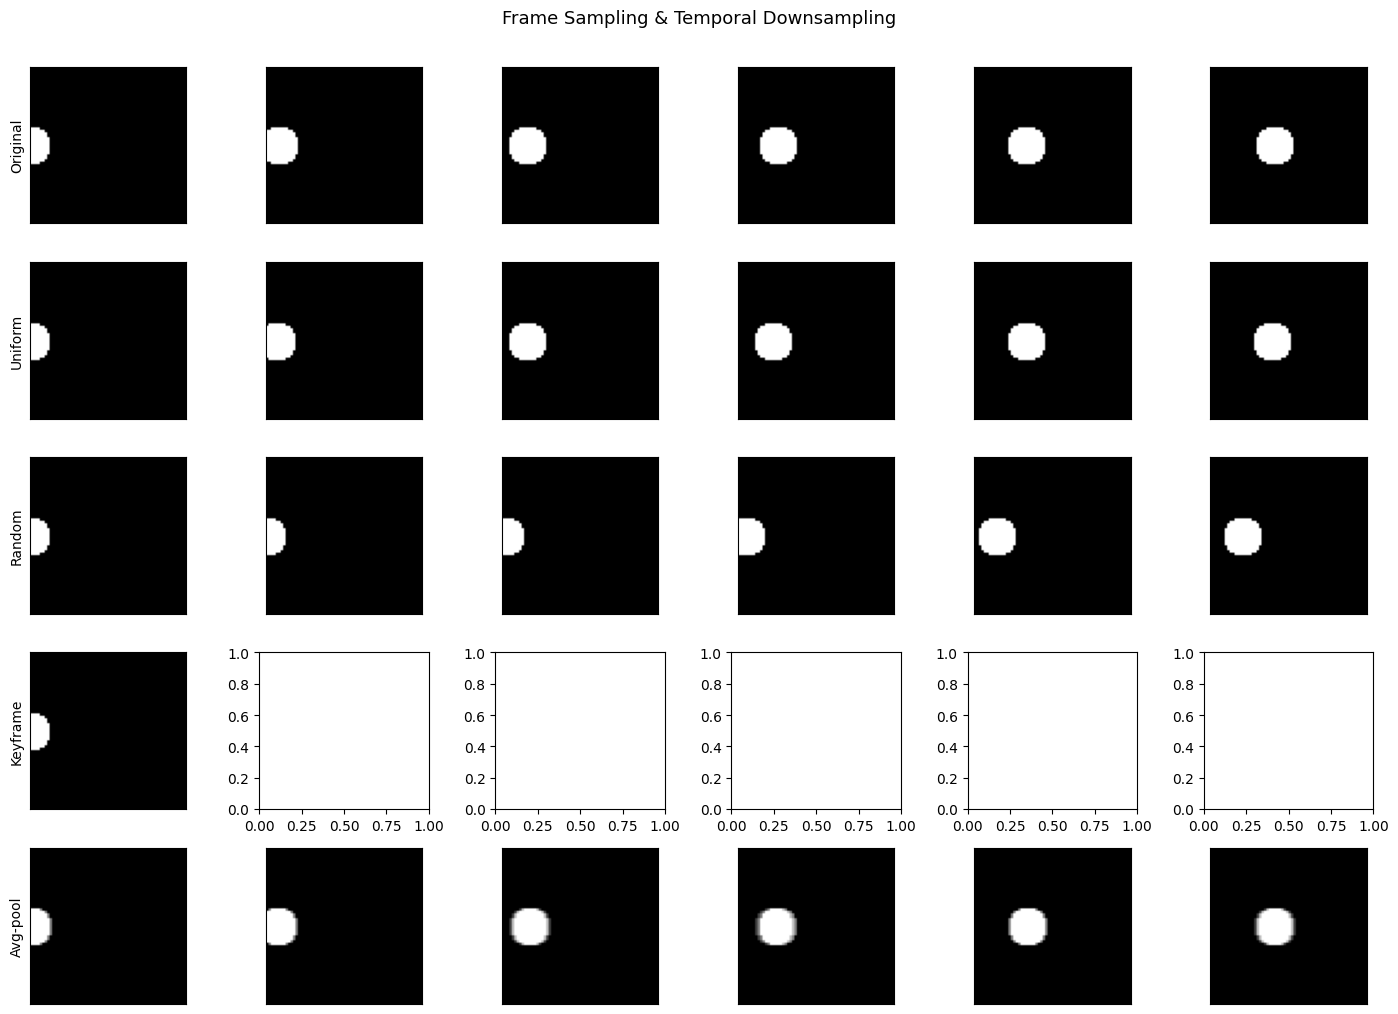


Plot saved as frame_sampling.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ─────────────────────────────────────────────────────────────
# Simulate a video: 120 frames, 30 FPS
# Each frame is a 64×64 grayscale image with a moving circle
# ─────────────────────────────────────────────────────────────
NUM_FRAMES = 120
FPS_ORIGINAL = 30
HEIGHT, WIDTH = 64, 64

def create_frame(frame_idx, total_frames, h=HEIGHT, w=WIDTH):
    """Draw a circle moving left to right across the frame."""
    frame = np.zeros((h, w), dtype=np.float32)
    # Circle center moves from left to right
    cx = int((frame_idx / total_frames) * w)
    cy = h // 2
    radius = 8
    for y in range(h):
        for x in range(w):
            if (x - cx)**2 + (y - cy)**2 < radius**2:
                frame[y, x] = 1.0
    return frame

print("Generating synthetic video...")
video = np.array([
    create_frame(i, NUM_FRAMES)
    for i in range(NUM_FRAMES)
])
print(f"  Video shape : {video.shape}  "
      f"(frames x height x width)")
print(f"  Original FPS: {FPS_ORIGINAL}")
print(f"  Duration    : {NUM_FRAMES/FPS_ORIGINAL:.1f} seconds\n")

# ─── Technique 1: Uniform frame sampling ──────────────────────
def uniform_sample(video, every_n):
    """Keep every N-th frame."""
    return video[::every_n]

# ─── Technique 2: Random frame sampling ───────────────────────
def random_sample(video, n_samples, seed=0):
    """Pick n_samples frames at random."""
    rng = np.random.default_rng(seed)
    idx = np.sort(rng.choice(len(video), n_samples, replace=False))
    return video[idx], idx

# ─── Technique 3: Keyframe sampling (scene change detection) ──
def keyframe_sample(video, threshold=0.05):
    """Keep frames where average pixel change exceeds threshold."""
    keyframes = [0]          # always keep the first frame
    for i in range(1, len(video)):
        diff = np.mean(np.abs(video[i] - video[i-1]))
        if diff > threshold:
            keyframes.append(i)
    return video[keyframes], keyframes

# Apply all three methods
every_n = 4
uniform   = uniform_sample(video, every_n)
n_rand    = NUM_FRAMES // every_n
rand_vid, rand_idx = random_sample(video, n_rand)
key_vid,  key_idx  = keyframe_sample(video, threshold=0.01)

print("=== Sampling Results ===")
print(f"Original  : {NUM_FRAMES} frames  @ {FPS_ORIGINAL} FPS")
print(f"Uniform   : {len(uniform)} frames  "
      f"(every {every_n} frames)   "
      f"@ {FPS_ORIGINAL//every_n} FPS equivalent")
print(f"Random    : {len(rand_vid)} frames  "
      f"(random subset)")
print(f"Keyframe  : {len(key_vid)} frames  "
      f"(scene-change based)")

# ─── Temporal downsampling: averaging ─────────────────────────
def temporal_average(video, window):
    """Average every 'window' consecutive frames into one."""
    n = len(video) // window
    return np.array([
        video[i*window:(i+1)*window].mean(axis=0)
        for i in range(n)
    ])

averaged = temporal_average(video, window=every_n)
print(f"Averaged  : {len(averaged)} frames  "
      f"(avg pool, window={every_n})")

# ─── Visualise ────────────────────────────────────────────────
show_frames = [0, 10, 20, 30, 40, 50]  # indices to display

fig, axes = plt.subplots(5, 6, figsize=(14, 10))
row_labels = ["Original", "Uniform", "Random",
              "Keyframe", "Avg-pool"]
datasets   = [
    (video,    show_frames),
    (uniform,  [min(i//every_n, len(uniform)-1)
                for i in show_frames]),
    (rand_vid, list(range(min(6, len(rand_vid))))),
    (key_vid,  list(range(min(6, len(key_vid))))),
    (averaged, [min(i//every_n, len(averaged)-1)
                for i in show_frames]),
]

for row, (ds, idxs) in enumerate(datasets):
    for col, fi in enumerate(idxs[:6]):
        ax = axes[row][col]
        ax.imshow(ds[fi], cmap='gray', vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=10)

plt.suptitle("Frame Sampling & Temporal Downsampling",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("frame_sampling.png", dpi=100)
plt.show()
print("\nPlot saved as frame_sampling.png")
